# Notebook — Teste do módulo `gravity.py`

Este notebook testa o módulo:

```python
geodesy/gravity.py
```

Serão testadas as funções:

- `newtonian_potential_point_mass`
- `newtonian_attraction_point_mass`
- `gravity_spherical_earth`
- `gravity_potential_spherical`
- `disturbing_potential_from_geoid`
- `radial_gravity_gradient_spherical`

Os exemplos incluem potencial de massa pontual, atração gravitacional, gravidade de Terra esférica, potencial gravitacional e gradiente radial.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import gravity
from geodesy import constants
from geodesy import ellipsoid
from geodesy import normal_gravity

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Potencial gravitacional de uma massa pontual


Potencial mínimo: 0.006674299999999999
Potencial máximo: 0.66743


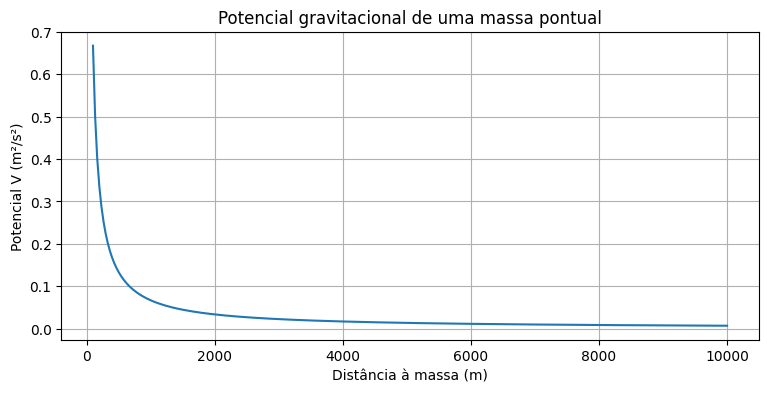

In [2]:
# ============================================================
# 1. POTENCIAL DE MASSA PONTUAL
# ============================================================

mass = 1.0e12  # kg
x = np.linspace(100, 10000, 300)
y = np.zeros_like(x)
z = np.zeros_like(x)

V = gravity.newtonian_potential_point_mass(x, y, z, mass)

print("Potencial mínimo:", np.min(V))
print("Potencial máximo:", np.max(V))

plt.figure(figsize=(9, 4))
plt.plot(x, V)
plt.xlabel("Distância à massa (m)")
plt.ylabel("Potencial V (m²/s²)")
plt.title("Potencial gravitacional de uma massa pontual")
plt.grid(True)
plt.show()


## 2. Atração gravitacional de uma massa pontual


Atração mínima: 6.674299999999999e-07 m/s²
Atração máxima: 0.006674299999999999 m/s²


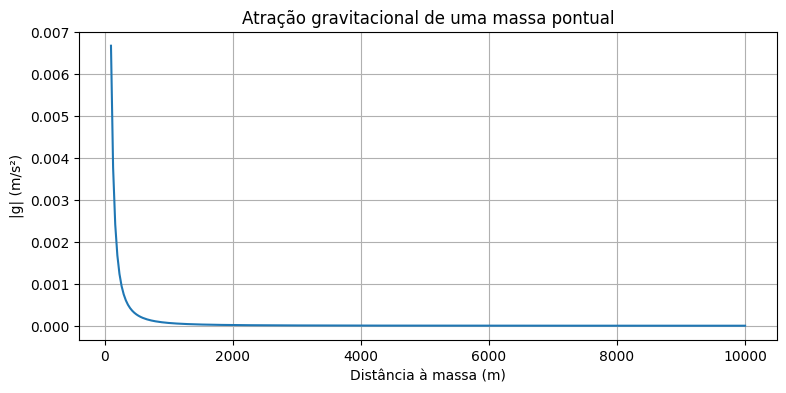

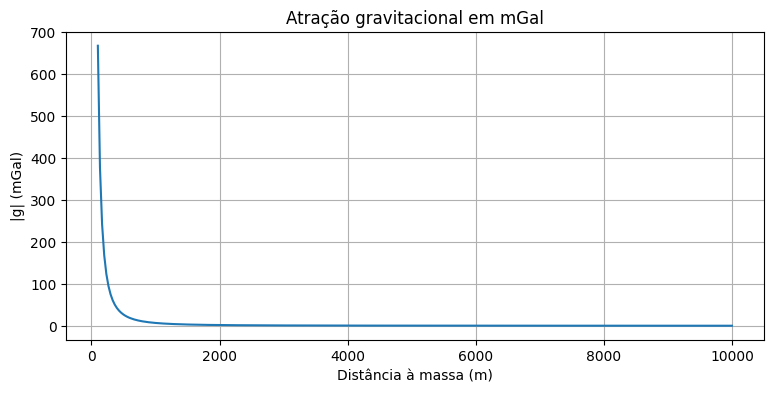

In [3]:
# ============================================================
# 2. ATRAÇÃO DE MASSA PONTUAL
# ============================================================

gx, gy, gz = gravity.newtonian_attraction_point_mass(x, y, z, mass)

g_abs = np.sqrt(gx**2 + gy**2 + gz**2)

print("Atração mínima:", np.min(g_abs), "m/s²")
print("Atração máxima:", np.max(g_abs), "m/s²")

plt.figure(figsize=(9, 4))
plt.plot(x, g_abs)
plt.xlabel("Distância à massa (m)")
plt.ylabel("|g| (m/s²)")
plt.title("Atração gravitacional de uma massa pontual")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(x, g_abs * constants.SI_TO_MGAL)
plt.xlabel("Distância à massa (m)")
plt.ylabel("|g| (mGal)")
plt.title("Atração gravitacional em mGal")
plt.grid(True)
plt.show()


## 3. Campo vetorial 2D de atração gravitacional


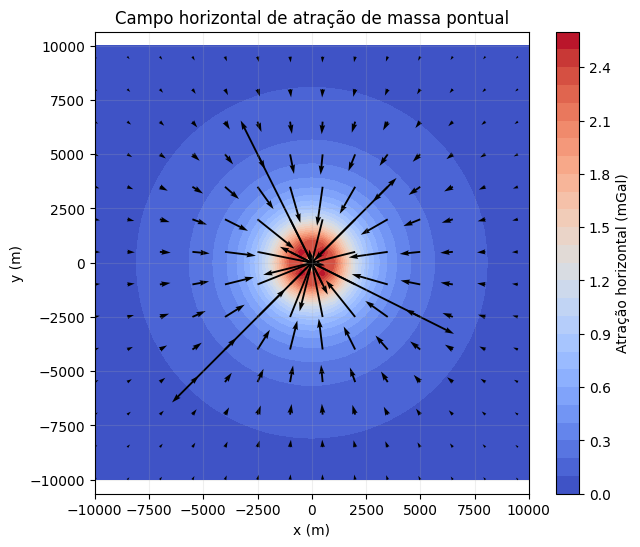

In [5]:
# ============================================================
# 3. CAMPO VETORIAL DE ATRAÇÃO
# ============================================================

xg = np.linspace(-10000, 10000, 41)
yg = np.linspace(-10000, 10000, 41)
X, Y = np.meshgrid(xg, yg)
Z = np.zeros_like(X) + 1000.0

gx2, gy2, gz2 = gravity.newtonian_attraction_point_mass(X, Y, Z, mass)
g_h = np.sqrt(gx2**2 + gy2**2)

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, g_h * constants.SI_TO_MGAL, cmap="coolwarm", levels=30)
plt.colorbar(label="Atração horizontal (mGal)")
plt.quiver(X[::3, ::3], Y[::3, ::3], gx2[::3, ::3], gy2[::3, ::3])
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Campo horizontal de atração de massa pontual")
plt.axis("equal")
plt.grid(alpha=0.2)
plt.show()


## 4. Gravidade de uma Terra esférica


g na superfície média: 9.820223358504759 m/s²
g a 1000 km: 7.336415442507821 m/s²


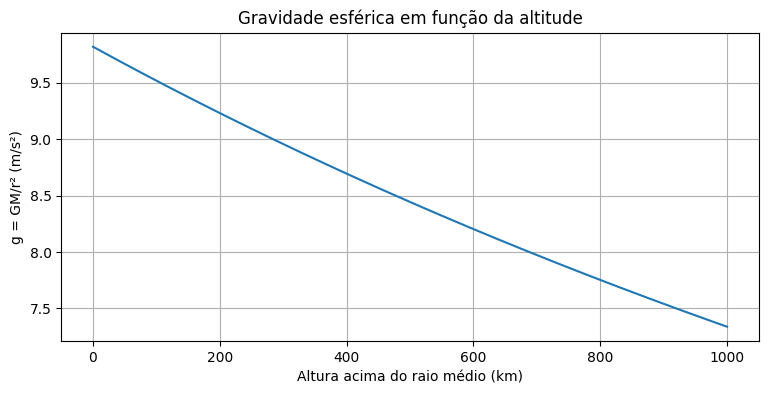

In [6]:
# ============================================================
# 4. GRAVIDADE ESFÉRICA
# ============================================================

r = np.linspace(constants.MEAN_EARTH_RADIUS, constants.MEAN_EARTH_RADIUS + 1000000, 300)
g_sph = gravity.gravity_spherical_earth(r)

print("g na superfície média:", g_sph[0], "m/s²")
print("g a 1000 km:", g_sph[-1], "m/s²")

plt.figure(figsize=(9, 4))
plt.plot((r - constants.MEAN_EARTH_RADIUS)/1000, g_sph)
plt.xlabel("Altura acima do raio médio (km)")
plt.ylabel("g = GM/r² (m/s²)")
plt.title("Gravidade esférica em função da altitude")
plt.grid(True)
plt.show()


## 5. Potencial gravitacional esférico


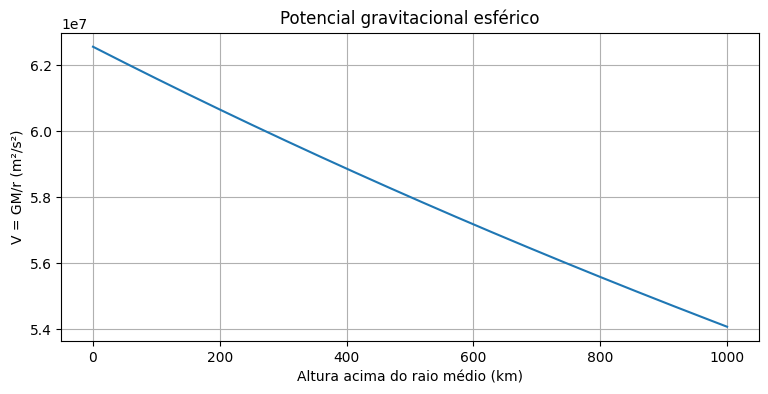

Potencial na superfície média: 62564729.43499937
Potencial a 1000 km: 54076782.78718104


In [7]:
# ============================================================
# 5. POTENCIAL ESFÉRICO
# ============================================================

V_sph = gravity.gravity_potential_spherical(r)

plt.figure(figsize=(9, 4))
plt.plot((r - constants.MEAN_EARTH_RADIUS)/1000, V_sph)
plt.xlabel("Altura acima do raio médio (km)")
plt.ylabel("V = GM/r (m²/s²)")
plt.title("Potencial gravitacional esférico")
plt.grid(True)
plt.show()

print("Potencial na superfície média:", V_sph[0])
print("Potencial a 1000 km:", V_sph[-1])


## 6. Gradiente radial da gravidade esférica


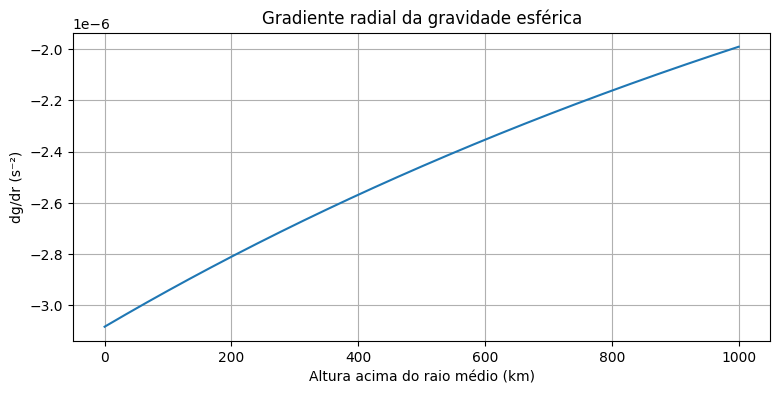

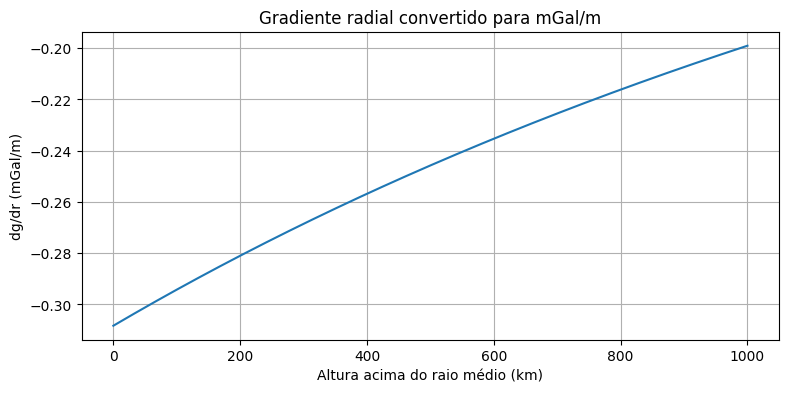

In [8]:
# ============================================================
# 6. GRADIENTE RADIAL
# ============================================================

dgdr = gravity.radial_gravity_gradient_spherical(r)

plt.figure(figsize=(9, 4))
plt.plot((r - constants.MEAN_EARTH_RADIUS)/1000, dgdr)
plt.xlabel("Altura acima do raio médio (km)")
plt.ylabel("dg/dr (s⁻²)")
plt.title("Gradiente radial da gravidade esférica")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot((r - constants.MEAN_EARTH_RADIUS)/1000, dgdr * constants.SI_TO_MGAL)
plt.xlabel("Altura acima do raio médio (km)")
plt.ylabel("dg/dr (mGal/m)")
plt.title("Gradiente radial convertido para mGal/m")
plt.grid(True)
plt.show()


## 7. Potencial perturbador a partir da ondulação geoidal


T mínimo: -48.901626679500005 m²/s²
T máximo: 147.48277406788523 m²/s²


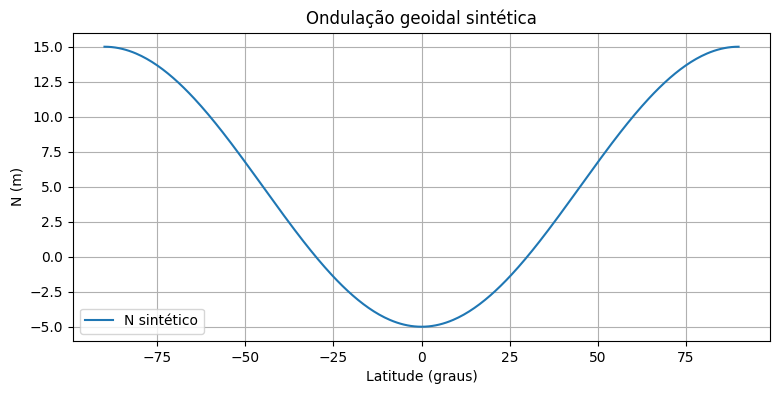

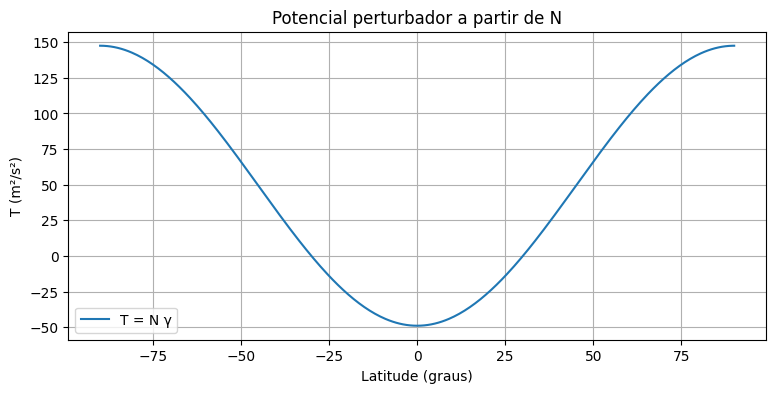

In [9]:
# ============================================================
# 7. POTENCIAL PERTURBADOR
# ============================================================

lat = np.linspace(-90, 90, 361)
gamma = normal_gravity.normal_gravity_somigliana(lat)

# Geoide sintético em metros
N = 20.0 * np.sin(np.deg2rad(lat))**2 - 5.0

T = gravity.disturbing_potential_from_geoid(N, gamma)

print("T mínimo:", np.min(T), "m²/s²")
print("T máximo:", np.max(T), "m²/s²")

plt.figure(figsize=(9, 4))
plt.plot(lat, N, label="N sintético")
plt.xlabel("Latitude (graus)")
plt.ylabel("N (m)")
plt.title("Ondulação geoidal sintética")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(lat, T, label="T = N γ")
plt.xlabel("Latitude (graus)")
plt.ylabel("T (m²/s²)")
plt.title("Potencial perturbador a partir de N")
plt.grid(True)
plt.legend()
plt.show()


## 8. Mapa global simples da gravidade esférica


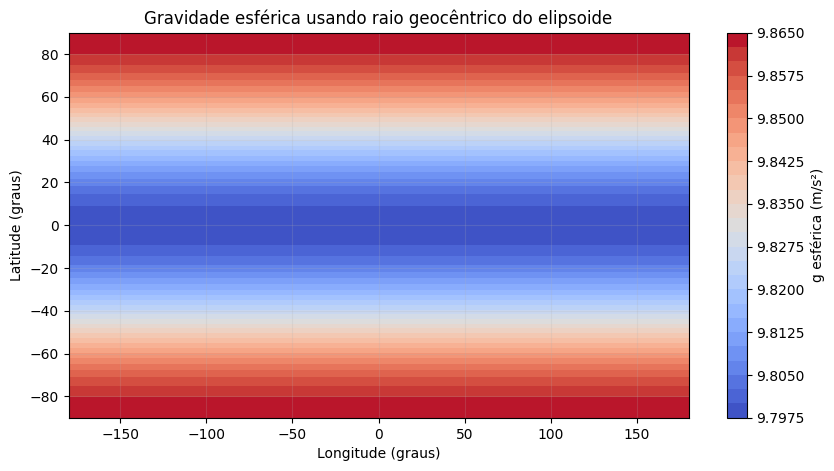

In [11]:
# ============================================================
# 8. MAPA GLOBAL DA GRAVIDADE ESFÉRICA
# ============================================================

lon = np.linspace(-180, 180, 361)
lat_grid = np.linspace(-90, 90, 181)
LON, LAT = np.meshgrid(lon, lat_grid)

R = ellipsoid.geocentric_radius(LAT)
G_GRID = gravity.gravity_spherical_earth(R)

plt.figure(figsize=(10, 5))
c = plt.contourf(LON, LAT, G_GRID, cmap="coolwarm", levels=30)
plt.colorbar(c, label="g esférica (m/s²)")
plt.xlabel("Longitude (graus)")
plt.ylabel("Latitude (graus)")
plt.title("Gravidade esférica usando raio geocêntrico do elipsoide")
plt.grid(alpha=0.2)
plt.show()


## 9. Comparação entre gravidade esférica e gravidade normal


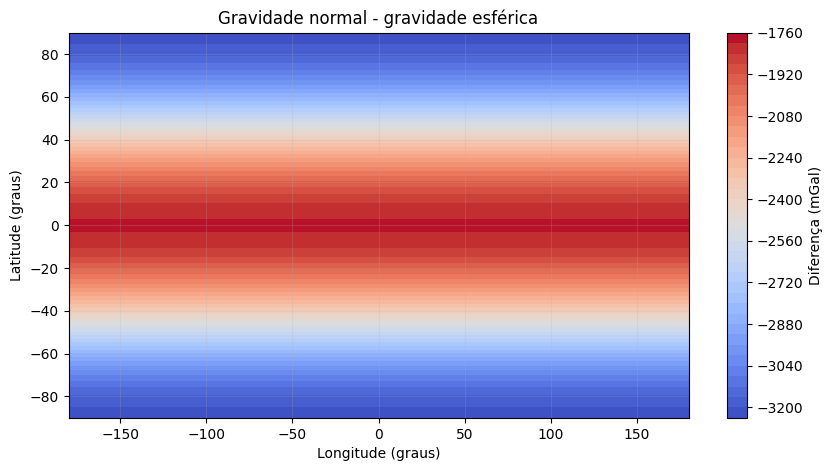

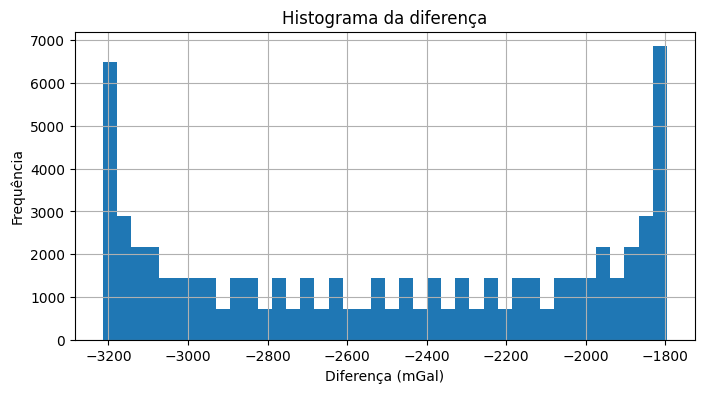

In [13]:
# ============================================================
# 9. DIFERENÇA ENTRE GRAVIDADE NORMAL E ESFÉRICA
# ============================================================

G_NORMAL = normal_gravity.normal_gravity_somigliana(LAT)
DIFF_MGAL = (G_NORMAL - G_GRID) * constants.SI_TO_MGAL

plt.figure(figsize=(10, 5))
c = plt.contourf(LON, LAT, DIFF_MGAL, cmap="coolwarm", levels=40)
plt.colorbar(c, label="Diferença (mGal)")
plt.xlabel("Longitude (graus)")
plt.ylabel("Latitude (graus)")
plt.title("Gravidade normal - gravidade esférica")
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(DIFF_MGAL.ravel(), bins=40)
plt.xlabel("Diferença (mGal)")
plt.ylabel("Frequência")
plt.title("Histograma da diferença")
plt.grid(True)
plt.show()


## 10. Resumo final


Se todas as células foram executadas sem erro, o módulo `gravity.py` está funcionando corretamente.

O próximo notebook testa:

```python
geodesy/heights.py
```
